# Pandas - Data Wrangling

## References Books, Sties and Online Tutorials

- [Brace, L.](https://exeter-qstep-resources.github.io/Q-Step_WS_06112019_Data_Analysis_and_visualisation_with_Python.pptx) 2019. Data Analysis and Visualisation with Python. Q-Step Workshop
- [Feldman, J.](http://jake-feldman.squarespace.com/data-science-python-oscm400c) Data Science - Python
- [Beuzen, T.](https://www.tomasbeuzen.com/python-programming-for-data-science/chapters/chapter8-wrangling-basics.html) Python Programming for Data Science

***

<font size="5">**Learning Objectives**</font><br>
<font size="3">After this session, you should be able to:</font>
- <font size="3">use built-in methods to analyse data on dataframe</font>
- <font size="3">manipulate dataset using pandas package: filter, groupby, sorting, create a new column, delete a column</font>

***

# Basic statistic using built-in methods

In [5]:
# import necessary libraries
import pandas as pd

# Open the apple stock data file
file_path = "data/apple_stock_data.csv"

try:
    df = pd.read_csv(file_path, header = 0)
except Exception as e:
    print (f"Exception - {e}")

In [3]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------- -------------------- 4.7/9.9 MB 31.0 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 44.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   --------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday
0,03-01-17,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday
1,04-01-17,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday
2,05-01-17,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday
3,06-01-17,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday
4,09-01-17,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday
...,...,...,...,...,...,...,...,...,...
164,28-08-17,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday
165,29-08-17,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday
166,30-08-17,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday
167,31-08-17,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday


In [7]:
# whenevery loading the dataset, please remember these 4 functions to apply
print (df.head(5)) # the first 5 rows
print (df.tail()) # it is display the last 5 rows of the df
print (df.info())  # display the complete information of the data types and null values etc.
print (df.describe()) # Descriptive statistics

       Date        Open        High         Low       Close   Adj Close  \
0  03-01-17  115.800003  116.330002  114.760002  116.150002  114.311760   
1  04-01-17  115.849998  116.510002  115.750000  116.019997  114.183815   
2  05-01-17  115.919998  116.860001  115.809998  116.610001  114.764473   
3  06-01-17  116.779999  118.160004  116.470001  117.910004  116.043915   
4  09-01-17  117.949997  119.430000  117.940002  118.989998  117.106812   

     Volume Month    Weekday  
0  28781900   Jan    Tuesday  
1  21118100   Jan  Wednesday  
2  22193600   Jan   Thursday  
3  31751900   Jan     Friday  
4  33561900   Jan     Monday  
         Date        Open        High         Low       Close   Adj Close  \
164  28-08-17  160.139999  162.000000  159.929993  161.470001  160.891617   
165  29-08-17  160.100006  163.119995  160.000000  162.910004  162.326462   
166  30-08-17  163.800003  163.889999  162.610001  163.350006  162.764893   
167  31-08-17  163.639999  164.520004  163.479996  164.

## sum() - return the sum of the values over the requested axis

In [10]:
# Compute sum of stock price at the closing of the trading day
sum_close = df["Close"].sum()
print (f"The sum of closing price = {sum_close}")

The sum of closing price = 24269.859941


In [25]:
# Compute sum of stock price at the opening and the closing for every rows: 
sum_open_close = df[['Close','Open']].sum()
print (f"The sum of open and close price = {sum_open_close}") 

The sum of open and close price = Close    24269.859941
Open     24245.720075
dtype: float64


In [26]:
# The magic of axis. Please note axis = 1 means columns and axis = 0 means rows
# lets add axis=1 in the parameter of the sum function and see the results
sum_open_close = df[['Close','Open']].sum(axis=1)
print (f"The sum of open and close price = {sum_open_close}") 

The sum of open and close price = 0      231.950005
1      231.869995
2      232.529999
3      234.690003
4      236.939995
          ...    
164    321.610000
165    323.010010
166    327.150009
167    327.639999
168    328.850006
Length: 169, dtype: float64


## eval() - evaluate a string describing operations on DataFrame columns

In [23]:
df_diff = df.eval('Close-Open')
print (f"The daily movement of stocks = {df_diff}")


The daily movement of stocks = 0      0.349999
1      0.169999
2      0.690003
3      1.130005
4      1.040001
         ...   
164    1.330002
165    2.809998
166   -0.449997
167    0.360001
168   -0.750000
Length: 169, dtype: float64


## max() - return the maximum of the values over the requested axis

In [31]:
# Compute the highest number of shares traded during the trading day
max_volume = df["Volume"].max()
print (f"The Max volume traded on a single day = {max_volume}")

The Max volume traded on a single day = 111985000


## min() - return the minimum of the values over the requested axis

In [32]:
# Compute the lowest of maximum stock price during the trading day

min_volume = df["Volume"].min()
print (f"The Min volume traded on a single day = {min_volume}")


The Min volume traded on a single day = 14246300


## mean() - return the mean of the values over the requested axis

In [33]:
# Compute average volume of trades done in the dataset
vol_mean = df["Volume"].mean()
print (f"The average volume traded on a single day = {vol_mean}")


The average volume traded on a single day = 26689994.082840238


In [37]:
# Compute mean of maximum and minimum stock price during the trading day
high_low_mean = df[['High','Low']].mean()
print (f"The average of High and Low price = \n{high_low_mean}")


The average of High and Low price = 
High    144.389704
Low     142.612840
dtype: float64


In [39]:
# Compute average close of trades done in the dataset
close_mean = df["Close"].mean()
print (f"The center of the Closing price = {close_mean}")

The center of the Closing price = 143.608638704142


## std() - return sample standard deviation over requested axis

In [38]:
# Compute standard deviation of stock price at the closing of the trading day
st_close = df["Close"].std()
print (f"The st div of the closing price of the stock = {st_close}")

The st div of the closing price of the stock = 11.780166091268997


Matplotlib is building the font cache; this may take a moment.


<Axes: ylabel='Frequency'>

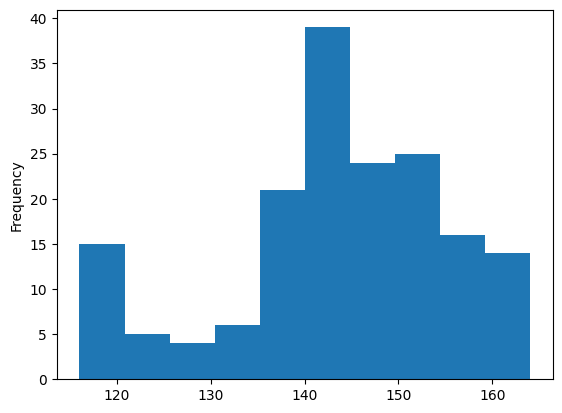

In [40]:
df.Close.plot.hist()

## describe() - generate descriptive statistics

In [41]:
# Compute key stats for every numeric column
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,169.000000,169.000000,169.000000,169.000000,169.000000,1.690000e+02
mean,143.465799,144.389704,142.612840,143.608639,142.225634,2.668999e+07
std,11.959822,12.021139,11.667212,11.780166,12.108588,1.139126e+07
min,115.800003,116.330002,114.760002,116.019997,114.183815,1.424630e+07
25%,138.850006,139.649994,138.600006,139.000000,137.393234,2.034630e+07
50%,144.190002,144.899994,143.309998,144.089996,142.859299,2.379350e+07
75%,153.419998,153.990005,152.220001,153.059998,151.617416,2.878190e+07
max,164.800003,164.940002,163.630005,164.050003,163.462372,1.119850e+08


In [43]:
# We can index and slice the above dataframe like any other dataframe.
summary = df.describe()
summary.loc[['mean','std'],['Open','Close']]

,Open,Close
mean,143.465799,143.608639
std,11.959822,11.780166


----

# Data Wrangling

<font size=3>A data wrangling process, also known as a data munging process, consists of reorganising, transforming and mapping data from one "raw" form into another in order to make it more usable and valuable for a variety of downstream uses including analytics.</font>

##  to_datetime(arg, format) - converts a Python object to datetime format
Where, format is a string representing the type of required date format. 
For year %y, For month %m, For day %d

- passing `format='ISO8601'` if your strings are all [ISO8601](https://en.wikipedia.org/wiki/ISO_8601) but not necessarily in exactly the same format;
- passing `format='mixed'`, and the format will be inferred for each element individually. This is risky, and you should probably use it along with `dayfirst=True`.
- see [strftime documentation](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior) for more information on choice.

In [45]:
df['Date'] = pd.to_datetime(df['Date'], format = "%d-%m-%y")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday


- <font>Converting data to datetime type in pandas allows for operations like calculating time differences and grouping by time units (e.g., year, month, day), which can't be done with string data. This enables more efficient time-based analysis and manipulation.</font>
- <font>You can extract the day, month, and year from the datetime objects using the .dt attribute:</font>
    - <font>dt.day - attribute to get the day.</font>
    - <font>dt.month - attribute to get the month.</font>
    - <font>dt.year - attribute to get the year.</font>

In [46]:
df.Date.dt.day

0       3
1       4
2       5
3       6
4       9
       ..
164    28
165    29
166    30
167    31
168     1
Name: Date, Length: 169, dtype: int32

In [47]:
df.Date.dt.month

0      1
1      1
2      1
3      1
4      1
      ..
164    8
165    8
166    8
167    8
168    9
Name: Date, Length: 169, dtype: int32

In [48]:
df.Date.dt.year

0      2017
1      2017
2      2017
3      2017
4      2017
       ... 
164    2017
165    2017
166    2017
167    2017
168    2017
Name: Date, Length: 169, dtype: int32

In [49]:
# Filter DataFrame for rows from February (month = 2)
feb_df = df.loc[df['Date'].dt.month == 2]
feb_df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday
20,2017-02-01,127.029999,130.490005,127.010002,128.750000,126.712341,111985000,Feb,Wednesday
21,2017-02-02,127.980003,129.389999,127.779999,128.529999,126.495819,33710400,Feb,Thursday
22,2017-02-03,128.309998,129.190002,128.160004,129.080002,127.037125,24507300,Feb,Friday
23,2017-02-06,129.130005,130.500000,128.899994,130.289993,128.227966,26845900,Feb,Monday
24,2017-02-07,130.539993,132.089996,130.449997,131.529999,129.448349,38183800,Feb,Tuesday
25,2017-02-08,131.350006,132.220001,131.220001,132.039993,129.950287,23004100,Feb,Wednesday
26,2017-02-09,131.649994,132.449997,131.119995,132.419998,130.889282,28349900,Feb,Thursday
27,2017-02-10,132.460007,132.940002,132.050003,132.119995,130.592758,20065500,Feb,Friday
28,2017-02-13,133.080002,133.820007,132.750000,133.289993,131.749222,23035400,Feb,Monday
29,2017-02-14,133.470001,135.089996,133.250000,135.020004,133.459244,33226200,Feb,Tuesday


## Create new columns

In [50]:
# Create a new column to store total sale price of a day
df['Total_sale'] = df[['Open','Close']].sum(axis=1)
df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995
...,...,...,...,...,...,...,...,...,...,...
164,2017-08-28,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday,321.610000
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999


In [ ]:
#Create a new Column to store different sale price using eval()
df['Diff'] = df.eval('Open-Close')
df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995,-0.169999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001
...,...,...,...,...,...,...,...,...,...,...,...
164,2017-08-28,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday,321.610000,-1.330002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001


In [52]:
#Create a new Column to store different sale price using eval()  -- Another way to do it
df.eval('AnotherDiff = Open-Close', inplace=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff,AnotherDiff
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999,-0.349999
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995,-0.169999,-0.169999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005,-1.130005
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001,-1.040001
...,...,...,...,...,...,...,...,...,...,...,...,...
164,2017-08-28,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday,321.610000,-1.330002,-1.330002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001,-0.360001


<div class="alert alert-block alert-info">
<ul>
 <li>The inplace argument works as follows:</li>
    <ul>
     <li>inplace = <b>True</b> : perform the evaluation on the dataframe and updating/modifying the original dataframe</li>
     <li> inplace = <b>False</b>: will return a copy of dataframe when the modified done -(default)</li>
    </ul>
</ul>

## Delete columns/rows

In [ ]:
# Delete column AnotherDiff we just created above with the drop method
df.drop('AnotherDiff', inplace = True, axis =1)
df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995,-0.169999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001
...,...,...,...,...,...,...,...,...,...,...,...
164,2017-08-28,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday,321.610000,-1.330002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001


In [54]:
#Delete rows with index 1 and 4
df_dummy = df.drop([1,4], inplace = False, axis =0)
df_dummy

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005
5,2017-01-10,118.769997,119.379997,118.300003,119.110001,117.224907,24462100,Jan,Tuesday,237.879998,-0.340004
6,2017-01-11,118.739998,119.930000,118.599998,119.750000,117.854782,27588600,Jan,Wednesday,238.489998,-1.010002
...,...,...,...,...,...,...,...,...,...,...,...
164,2017-08-28,160.139999,162.000000,159.929993,161.470001,160.891617,25966000,Aug,Monday,321.610000,-1.330002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001


<div class="alert alert-block alert-info">
<ul>
 <li>The inplace argument works as follows:</li>
    <ul>
     <li>inplace = <b>True</b> : delete the given column(s) permanently from original dataframe</li>
     <li> inplace = <b>False</b>: will return a copy of dataframe where the removing is done - (default)</li>
    </ul>
 <li>The axis argument works as follows:</li>
    <ul>
     <li>axis = <b>1</b> : delete columns given</li>
     <li>axis = <b>0</b> : delete rows given</li>
    </ul>
</ul>
</div>

## Sorting
Let's see how we can sort a data frame.  The inplace argument has the same effect as the drop method.

In [56]:
#Sort the data frame according to the Volume Column from small to large
#By setting inplace= False will just return the sorted dataframe and not change df 
sorted_df = df.sort_values(by = ['Volume'], inplace=False, ascending=True)
sorted_df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
79,2017-04-27,143.919998,144.160004,143.309998,143.789993,142.127869,14246300,Apr,Thursday,287.709991,0.130005
125,2017-07-03,144.880005,145.300003,143.100006,143.500000,142.426682,14258300,Jul,Monday,288.380005,1.380005
72,2017-04-18,141.410004,142.039993,141.110001,141.199997,139.567795,14697500,Apr,Tuesday,282.610001,0.210007
48,2017-03-14,139.300003,139.649994,138.839996,138.990005,137.383347,15309100,Mar,Tuesday,278.290008,0.309998
141,2017-07-26,153.350006,153.929993,153.059998,153.460007,152.312180,15781000,Jul,Wednesday,306.810013,-0.110001
...,...,...,...,...,...,...,...,...,...,...,...
93,2017-05-17,153.600006,154.570007,149.710007,150.250000,149.126190,50767700,May,Wednesday,303.850006,3.350006
109,2017-06-09,155.190002,155.190002,146.020004,148.979996,147.865692,64882700,Jun,Friday,304.169998,6.210006
146,2017-08-02,159.279999,159.750000,156.160004,157.139999,155.964661,69936800,Aug,Wednesday,316.419998,2.140000
110,2017-06-12,145.740005,146.089996,142.509995,145.419998,144.332306,72307300,Jun,Monday,291.160003,0.320007


In [58]:
#Sort the dataframe according to the Volume Column from large to small and replace the original df
sorted_df.sort_values(by = ['Volume'], inplace=True, ascending=False)
sorted_df

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
20,2017-02-01,127.029999,130.490005,127.010002,128.750000,126.712341,111985000,Feb,Wednesday,255.779999,-1.720001
110,2017-06-12,145.740005,146.089996,142.509995,145.419998,144.332306,72307300,Jun,Monday,291.160003,0.320007
146,2017-08-02,159.279999,159.750000,156.160004,157.139999,155.964661,69936800,Aug,Wednesday,316.419998,2.140000
109,2017-06-09,155.190002,155.190002,146.020004,148.979996,147.865692,64882700,Jun,Friday,304.169998,6.210006
93,2017-05-17,153.600006,154.570007,149.710007,150.250000,149.126190,50767700,May,Wednesday,303.850006,3.350006
...,...,...,...,...,...,...,...,...,...,...,...
141,2017-07-26,153.350006,153.929993,153.059998,153.460007,152.312180,15781000,Jul,Wednesday,306.810013,-0.110001
48,2017-03-14,139.300003,139.649994,138.839996,138.990005,137.383347,15309100,Mar,Tuesday,278.290008,0.309998
72,2017-04-18,141.410004,142.039993,141.110001,141.199997,139.567795,14697500,Apr,Tuesday,282.610001,0.210007
125,2017-07-03,144.880005,145.300003,143.100006,143.500000,142.426682,14258300,Jul,Monday,288.380005,1.380005


In [60]:
#Sort the dataframe according to the Weekday Column from first day of the weekday to last day of weekday
# Lets have the ranking first
day_ranking = {'Monday':0,
               'Tuesday':1,
               'Wednesday':2,
               'Thursday':3,
               'Friday':4}

weekday_sorted = df.sort_values(by = ['Weekday'], inplace=False, ascending=True, key=lambda x: x.map(day_ranking))
weekday_sorted

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001
13,2017-01-23,120.000000,120.809998,119.769997,120.080002,118.179558,22050200,Jan,Monday,240.080002,-0.080002
23,2017-02-06,129.130005,130.500000,128.899994,130.289993,128.227966,26845900,Feb,Monday,259.419998,-1.159988
18,2017-01-30,120.930000,121.629997,120.660004,121.629997,119.705017,30377500,Jan,Monday,242.559997,-0.699997
28,2017-02-13,133.080002,133.820007,132.750000,133.289993,131.749222,23035400,Feb,Monday,266.369995,-0.209991
...,...,...,...,...,...,...,...,...,...,...,...
133,2017-07-14,147.970001,149.330002,147.330002,149.039993,147.925232,20132100,Jul,Friday,297.009994,-1.069992
128,2017-07-07,142.899994,144.750000,142.899994,144.179993,143.101578,19201700,Jul,Friday,287.079987,-1.279999
138,2017-07-21,149.990005,150.440002,148.880005,150.270004,149.146042,26252600,Jul,Friday,300.260009,-0.279999
163,2017-08-25,159.649994,160.559998,159.270004,159.860001,159.287384,25480100,Aug,Friday,319.509995,-0.210007


We can also sort the values of the Series using the sort_values() function.<br>
Sorting the closing prices

In [61]:
#select only the "Close" price
sorted_close = df.sort_values(by = ['Close'], inplace=False, ascending=True)
sorted_close

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995,-0.169999
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001
...,...,...,...,...,...,...,...,...,...,...,...
155,2017-08-15,160.660004,162.199997,160.139999,161.600006,161.021149,29465500,Aug,Tuesday,322.260010,-0.940002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001


Now let's sort by multiple columns, specifying more than one column is essentially specifying a tie break

In [ ]:
#Sort by Weekday and Close price

sorted_multi = df.sort_values(by = ['Weekday','Close'], inplace=False, ascending=True)
sorted_multi

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
1,2017-01-04,115.849998,116.510002,115.750000,116.019997,114.183815,21118100,Jan,Wednesday,231.869995,-0.169999
0,2017-01-03,115.800003,116.330002,114.760002,116.150002,114.311760,28781900,Jan,Tuesday,231.950005,-0.349999
2,2017-01-05,115.919998,116.860001,115.809998,116.610001,114.764473,22193600,Jan,Thursday,232.529999,-0.690003
3,2017-01-06,116.779999,118.160004,116.470001,117.910004,116.043915,31751900,Jan,Friday,234.690003,-1.130005
4,2017-01-09,117.949997,119.430000,117.940002,118.989998,117.106812,33561900,Jan,Monday,236.939995,-1.040001
...,...,...,...,...,...,...,...,...,...,...,...
155,2017-08-15,160.660004,162.199997,160.139999,161.600006,161.021149,29465500,Aug,Tuesday,322.260010,-0.940002
165,2017-08-29,160.100006,163.119995,160.000000,162.910004,162.326462,29516900,Aug,Tuesday,323.010010,-2.809998
166,2017-08-30,163.800003,163.889999,162.610001,163.350006,162.764893,27269600,Aug,Wednesday,327.150009,0.449997
167,2017-08-31,163.639999,164.520004,163.479996,164.000000,163.412552,26785100,Aug,Thursday,327.639999,-0.360001


In [64]:
#Sort by Volume and Close price

sorted_multi = df.sort_values(by = ['Volume','Close'], inplace=False, ascending=True)
sorted_multi

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
79,2017-04-27,143.919998,144.160004,143.309998,143.789993,142.127869,14246300,Apr,Thursday,287.709991,0.130005
125,2017-07-03,144.880005,145.300003,143.100006,143.500000,142.426682,14258300,Jul,Monday,288.380005,1.380005
72,2017-04-18,141.410004,142.039993,141.110001,141.199997,139.567795,14697500,Apr,Tuesday,282.610001,0.210007
48,2017-03-14,139.300003,139.649994,138.839996,138.990005,137.383347,15309100,Mar,Tuesday,278.290008,0.309998
141,2017-07-26,153.350006,153.929993,153.059998,153.460007,152.312180,15781000,Jul,Wednesday,306.810013,-0.110001
...,...,...,...,...,...,...,...,...,...,...,...
93,2017-05-17,153.600006,154.570007,149.710007,150.250000,149.126190,50767700,May,Wednesday,303.850006,3.350006
109,2017-06-09,155.190002,155.190002,146.020004,148.979996,147.865692,64882700,Jun,Friday,304.169998,6.210006
146,2017-08-02,159.279999,159.750000,156.160004,157.139999,155.964661,69936800,Aug,Wednesday,316.419998,2.140000
110,2017-06-12,145.740005,146.089996,142.509995,145.419998,144.332306,72307300,Jun,Monday,291.160003,0.320007


## groupby
<font szie=3>Using <b>groupby</b> method we can:</font>
- <font szie=3>Split the data into groups based on some criteria</font>
- <font szie=3>Calculate statistics (or apply a function) to each group</font>

In [66]:
# Group apple stock price by month
stocks_by_month = df.groupby('Month')
stocks_by_month

In [67]:
#Use a for loop to iterate through the key, item pairs in the DataFrameGroupBy object
for group, items in stocks_by_month:
    print(f"Group: {group}")
    print(items)

Group: Apr
         Date        Open        High         Low       Close   Adj Close  \
62 2017-04-03  143.710007  144.119995  143.050003  143.699997  142.038910   
63 2017-04-04  143.250000  144.889999  143.169998  144.770004  143.096542   
64 2017-04-05  144.220001  145.460007  143.809998  144.020004  142.355209   
65 2017-04-06  144.289993  144.520004  143.449997  143.660004  141.999374   
66 2017-04-07  143.729996  144.179993  143.270004  143.339996  141.683060   
67 2017-04-10  143.600006  143.880005  142.899994  143.169998  141.515030   
68 2017-04-11  142.940002  143.350006  140.059998  141.630005  139.992844   
69 2017-04-12  141.600006  142.149994  141.009995  141.800003  140.160873   
70 2017-04-13  141.910004  142.380005  141.050003  141.050003  139.419540   
71 2017-04-17  141.479996  141.880005  140.869995  141.830002  140.190521   
72 2017-04-18  141.410004  142.039993  141.110001  141.199997  139.567795   
73 2017-04-19  141.880005  142.000000  140.449997  140.679993  13

We can determine the number of rows in each group using the size method, which tells us the `size` of each group.

In [68]:
# get the total number of row count for each group
df.groupby('Month').size()


Month
Apr    19
Aug    23
Feb    19
Jan    20
Jul    20
Jun    22
Mar    23
May    22
Sep     1
dtype: int64

In [71]:
# Access individual group using DataFrameGroupBy.get_group(key)
stocks_by_month.get_group('Mar')

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Weekday,Total_sale,Diff
39,2017-03-01,137.889999,140.149994,137.600006,139.789993,138.174088,36414600,Mar,Wednesday,277.679992,-1.899994
40,2017-03-02,140.000000,140.279999,138.759995,138.960007,137.353699,26211000,Mar,Thursday,278.960007,1.039993
41,2017-03-03,138.779999,139.830002,138.589996,139.779999,138.164200,21108100,Mar,Friday,278.559998,-1.000000
42,2017-03-06,139.369995,139.770004,138.600006,139.339996,137.729309,21750000,Mar,Monday,278.709991,0.029999
43,2017-03-07,139.059998,139.979996,138.789993,139.520004,137.907227,17446300,Mar,Tuesday,278.580002,-0.460006
44,2017-03-08,138.949997,139.800003,138.820007,139.000000,137.393234,18707200,Mar,Wednesday,277.949997,-0.050003
45,2017-03-09,138.740005,138.789993,137.050003,138.679993,137.076920,22155900,Mar,Thursday,277.419998,0.060012
46,2017-03-10,139.250000,139.360001,138.639999,139.139999,137.531601,19612800,Mar,Friday,278.389999,0.110001
47,2017-03-13,138.850006,139.429993,138.820007,139.199997,137.590912,17421700,Mar,Monday,278.050003,-0.349991
48,2017-03-14,139.300003,139.649994,138.839996,138.990005,137.383347,15309100,Mar,Tuesday,278.290008,0.309998


In [75]:
#Calculate mean value for open price in each month
df.groupby('Month').Open.mean()

Month
Apr    143.030001
Aug    158.946958
Feb    133.234738
Jan    119.093499
Jul    148.096500
Jun    148.215001
Mar    140.362174
May    151.965908
Sep    164.800003
Name: Open, dtype: float64

We can also group datetime values in a DataFrame to calculate statistics like averages or counts over time periods such as days, weeks, or months.

In [76]:
# Group by month and calculate average closing price
df.groupby(df.Date.dt.month).Close.mean()

Date
1    119.570000
2    133.714209
3    140.617826
4    142.886842
5    152.227726
6    147.831362
7    148.299499
8    159.021306
9    164.050003
Name: Close, dtype: float64

Once groupby object is create we can calculate various statistics for each group

In [78]:
#Find the average open price and the average volume in each month. 
df.groupby('Month')[['Open','Volume']].mean()

,Open,Volume
Month,,
Apr,143.030001,1.964758e+07
Aug,158.946958,2.874213e+07
Feb,133.234738,3.026151e+07
Jan,119.093499,2.815610e+07
Jul,148.096500,2.109962e+07
Jun,148.215001,3.109900e+07
Mar,140.362174,2.441863e+07
May,151.965908,2.971615e+07
Sep,164.800003,1.659110e+07


<font size=3>You can specify a list of column names for the argument in the group by to accomplish this.</font>

In [79]:
#Groubpy multiple columns: open price for each month and each day of the week.
df.groupby(['Month','Weekday']).Open.mean()

Month  Weekday  
Apr    Friday       143.419998
       Monday       143.072502
       Thursday     142.834999
       Tuesday      142.877502
       Wednesday    143.042503
Aug    Friday       157.545002
       Monday       158.505001
       Thursday     160.307999
       Tuesday      157.338004
       Wednesday    160.670001
Feb    Friday       132.945004
       Monday       133.116669
       Thursday     133.170000
       Tuesday      134.329998
       Wednesday    132.582501
Jan    Friday       119.619999
       Monday       119.626666
       Thursday     118.972500
       Tuesday      118.722000
       Wednesday    118.752499
Jul    Friday       147.687500
       Monday       147.658002
       Thursday     148.442501
       Tuesday      148.576665
       Wednesday    148.347500
Jun    Friday       148.426001
       Monday       147.727501
       Thursday     148.444003
       Tuesday      148.234997
       Wednesday    148.132503
Mar    Friday       140.850000
       Monday       13

<font size=3>Now, we have a group for every month + weekday combination. The above is a series with multi-level, we can slice these series by resetting the index, which will move the multilevel index to columns in your dataframe.</font>

In [81]:
df.groupby(['Month','Weekday']).Open.mean().reset_index()

,Month,Weekday,Open
0,Apr,Friday,143.419998
1,Apr,Monday,143.072502
2,Apr,Thursday,142.834999
3,Apr,Tuesday,142.877502
4,Apr,Wednesday,143.042503
5,Aug,Friday,157.545002
6,Aug,Monday,158.505001
7,Aug,Thursday,160.307999
8,Aug,Tuesday,157.338004
9,Aug,Wednesday,160.670001


## Filtering Rows
<font size=3>In this section, we will see how to select only the rows of a dataframe that satisfy certain condition(s).</font>
- <font size=3>Filtering is performed using so-called Boolean arrays</font>
- <font size=3>To subset the data we can apply Boolean indexing. This indexing is commonly known as a filter</font>
- <font size=3>Any Boolean operator can be used to subset the data:</font>
    - <font size=3> <b> $>$ </b> greater</font>
    - <font size=3><b> $<$ </b> less</font>
    - <font size=3><b> $==$ </b> equal</font>
    - <font size=3><b> $>=$ </b> greater or equal</font>
    - <font size=3><b> $<=$ </b> less or equal</font>
    - <font size=3><b> $!=$ </b> not equal</font>

The data was extracted from the 1974 Motor Trend US magazine, and comprises fuel consumption and 10 aspects of automobile design and performance for 32 automobiles (1973–74 models).
- mpg: Miles/(US) gallon
- cyl: Number of cylinders
- disp: Displacement (cu.in.)
- hp: Gross horsepower
- drat: Rear axle ratio
- wt: Weight (1000 lbs)
- qsec: 1/4 mile time
- vs: V/S
- am: Transmission (0 = automatic, 1 = manual)
- gear: Number of forward gears
- carb: Number of carburetors

In [82]:
# import necessary libraries
import pandas as pd

# Open the apple stock data file
file_path = "data/mtcars.csv"

try:
    cardf = pd.read_csv(file_path, header = 0)
except Exception as e:
    print (f"Exception - {e}")

cardf

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [83]:
#Picking out rows that only correspond to cars with >=150 hp + all columns
hp_150_df = cardf.loc[cardf.hp >= 150, :]
hp_150_df

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
11,Merc 450SE,16.4,8,275.8,180,3.07,4.070,17.40,0,0,3,3
12,Merc 450SL,17.3,8,275.8,180,3.07,3.730,17.60,0,0,3,3
13,Merc 450SLC,15.2,8,275.8,180,3.07,3.780,18.00,0,0,3,3
14,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
15,Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4
16,Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4
21,Dodge Challenger,15.5,8,318.0,150,2.76,3.520,16.87,0,0,3,2
22,AMC Javelin,15.2,8,304.0,150,3.15,3.435,17.30,0,0,3,2


In [84]:
#Select our cars with am = 1 and only look at columns mpg, hp, am
am_df = cardf.loc[cardf.am == 1, ['mpg','hp','am']]
am_df

,mpg,hp,am
0,21.0,110,1
1,21.0,110,1
2,22.8,93,1
17,32.4,66,1
18,30.4,52,1
19,33.9,65,1
25,27.3,66,1
26,26.0,91,1
27,30.4,113,1
28,15.8,264,1


<font size=3>We can filter rows based on conditions from a Series as well.</font>

In [ ]:
#Select our cars with am = 1 and only look at columns mpg
am_mpg_df = cardf.loc[cardf.am == 1, 'mpg']
am_mpg_df

0     21.0
1     21.0
2     22.8
17    32.4
18    30.4
19    33.9
25    27.3
26    26.0
27    30.4
28    15.8
29    19.7
30    15.0
31    21.4
Name: mpg, dtype: float64

<font size=3>Filter on multiple condition. For an "and" clause use & and for an "or" clause use |. Make sure to put each clause in parentheses. </font>

In [88]:
#Select all cars with 6 cylinders and 4 gears + all columns
cyl_gear_df = cardf.loc[(cardf.cyl == 6) & (cardf.gear == 4), :]
cyl_gear_df

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
10,Merc 280C,17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4


In [90]:
#Select all cars with either 4 or 6 cylinders and show only mpg, hp, and gear
cyl_or_gear_df = cardf.loc[(cardf.cyl == 6) | (cardf.gear == 4), :]
cyl_or_gear_df

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
10,Merc 280C,17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1


<font size=3>We can also use a variable in the conditions</font>

In [92]:
tr = int (input ("Enter transmission type [0=auto and 1=manual]:"))
hrp = int (input("Enter horse power:"))

cardf.loc[(cardf.am==tr) & (cardf.hp==hrp),:] 

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.9,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.9,2.875,17.02,0,1,4,4


***

# Summary

- <font size=3>We can perfrom basic calculation on a dataframe: mean(), max(), min(), describe(), std(), sum()</font>
- <font size=3>We can create new columns and delete columns in a dataframe<</font>
- <font size=3>Useful a dataframe manipulations:groupby(), sort_values(), filter()</font>

***